# Initial Data Analysis

In [53]:
import matplotlib.pyplot as plt

from bioacoustics.data import load_metadata
from bioacoustics.preprocessing import get_labels

from bioacoustics.visualization import (
    plot_label_frequency,
    plot_active_labels,
    plot_label_concurrence,
    set_style,
)

set_style()

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load metadata and get labels

In [54]:
df_train, df_train_soundscapes, df_taxonomy = load_metadata()
y_class, y_primary = get_labels(df_train, df_taxonomy)
y_class_soundscapes, y_primary_soundscapes = get_labels(df_train_soundscapes, df_taxonomy)

In [55]:
df_train.head()

,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,collection
filename,,,,,,,,,,,,,,
1161364/iNat1216197.ogg,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,iNat
1161364/iNat1114648.ogg,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,iNat
1161364/iNat810195.ogg,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,iNat
1161364/iNat818781.ogg,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/818781.m...,iNat
1161364/iNat556514.ogg,1161364,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/556514.m...,iNat


In [56]:
df_train_soundscapes.head()

primary_label
filename                                  start    end                                     
BC2026_Train_0039_S22_20211231_201500.ogg 00:00:00 00:00:05  22961;23158;24321;517063;65380
                                          00:00:05 00:00:10  22961;23158;24321;517063;65380
                                          00:00:10 00:00:15  22961;23158;24321;517063;65380
                                          00:00:15 00:00:20  22961;23158;24321;517063;65380
                                          00:00:20 00:00:25  22961;23158;24321;517063;65380

## Stats on metadata

<div style="color:red"> TODO: explore the metadata features, think how to integrate them </div>

For now I am going to ignore the secondary labels as they concern only a small fraction of the data.

In [57]:
print(
    f"Percentage of train audio with secondary labels: {(df_train['secondary_labels'] != '[]').sum() / len(df_train) * 100:.2f}%"
)

Percentage of train audio with secondary labels: 12.30%


There are very many different types of calls, songs, etc... It would likely make sense combine them into different categories e.g. songs, calls, etc so that there can be clearer similarities between the calories. I've listed them here.

In [58]:
import ast

possible_types = {
    t
    for lst in df_train["type"].unique()
    for t in ast.literal_eval(lst)
}

print(possible_types)

{'', ' calls from pair at nest hole', ' howler monkeys', 'moan', " 'laughing' song", ' communal murmuring of flock', ' dogs', 'mechanical sound', ' flight call', ' song (variant)', ' calls by perched pair and begging young', ' Psits', ' whistle. (probably alarm) calls', ' also doing cracks (estalos in port.)', ' wing-flapping', ' ?', ' songs a and b and calls', ' song on perch. distant calls in flight.', ' fast and normal song', ' nuptial song', ' begging calls of 2 fledged juveniles', ' morning chorus', ' two-note call.', 'automoviles', 'chamado estranho', ' daytime duet calls', ' flight calls of 16 pairs', ' bill snapping', ' chatters calls', ' (slow) alternate song', ' calls of c 10 birds while foraging on forest floor', ' song b in duet and calls', ' pheugopedius mystacalis', ' Take-off calls', ' squabble in flight', ' wing sound', " dawn 'songs'", ' night flight call', ' hatchling or nestling', ' half song', ' calls 2 birds on ground', ' (probably alarm) calls', ' call of a juveni

## Stats on labels

In [59]:
print(f"Number of Classes: {df_taxonomy["class_name"].nunique()}")
print(f"Number of Species: {df_taxonomy["primary_label"].nunique()}")

Number of Classes: 5
Number of Species: 234


### Train data

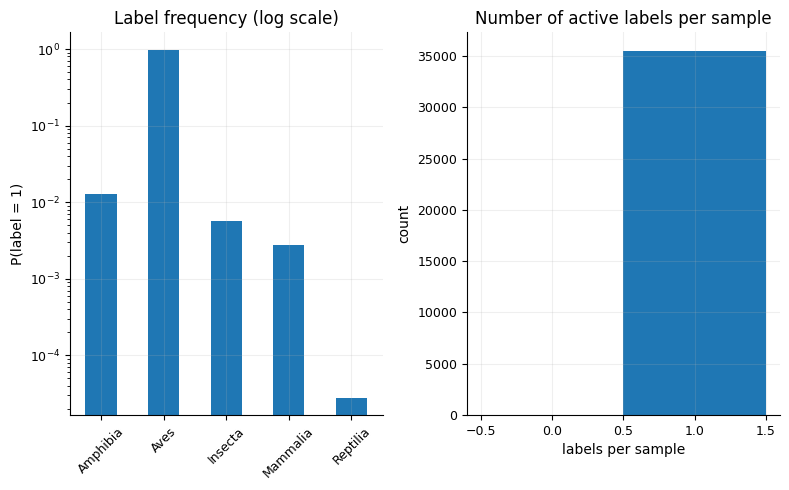

In [60]:
fig, axes = plt.subplots(1,2)
plot_label_frequency(y_class, ax=axes[0])
plot_active_labels(y_class, ax=axes[1])
plt.tight_layout()
plt.show()

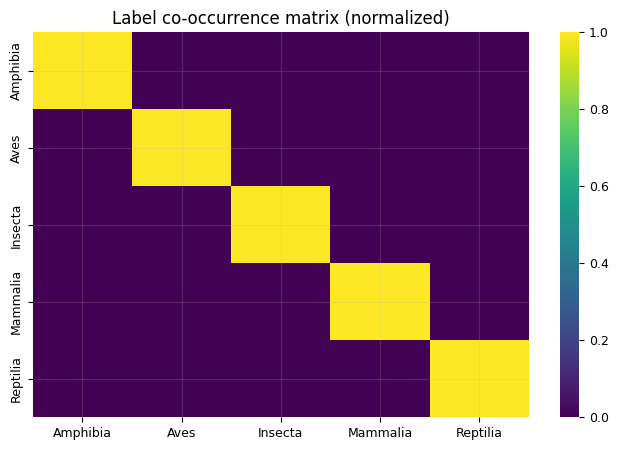

In [61]:
plot_label_concurrence(y_class)

### Train soundscapes

Resemble the test data.

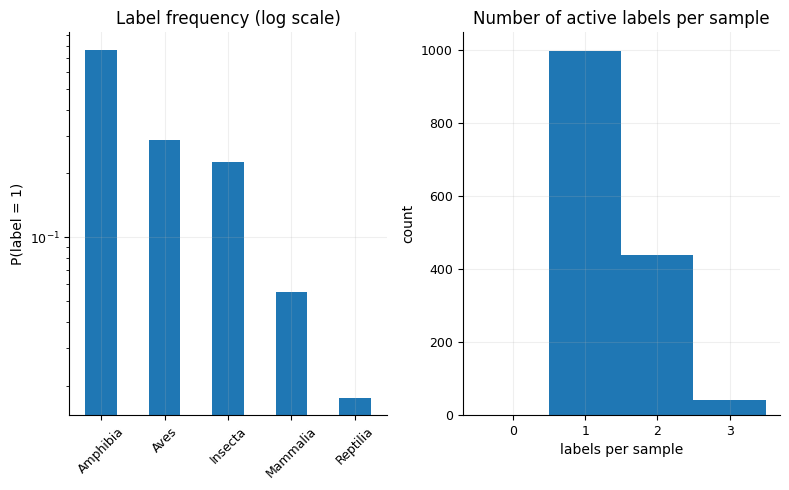

In [62]:
fig, axes = plt.subplots(1, 2)
plot_label_frequency(y_class_soundscapes, ax=axes[0])
plot_active_labels(y_class_soundscapes, ax=axes[1])
plt.tight_layout()
plt.show()

In [63]:
y_class_soundscapes.value_counts()

Amphibia  Aves  Insecta  Mammalia  Reptilia
1         0     0        0         0           866
          1     0        0         0           188
0         1     1        0         0           162
          0     1        0         0            78
1         0     1        0         0            46
0         1     0        0         0            30
1         1     0        1         0            26
0         0     0        1         0            24
                1        1         0            22
                         0         1            12
          1     1        0         1            12
1         0     0        1         0             4
0         1     0        1         0             4
1         1     1        0         0             2
0         0     1        1         1             2
Name: count, dtype: int64

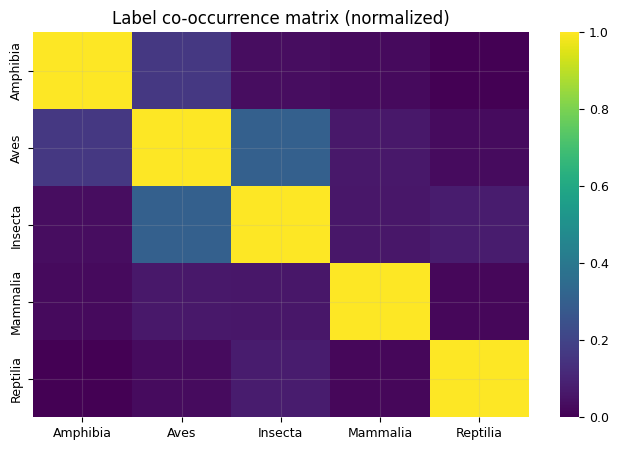

In [64]:
plot_label_concurrence(y_class_soundscapes)